# Stroop — basic analysis

Loads a Stroop task export (real data if you've played it, a synthetic sample otherwise), computes mean RT, accuracy, and the classic Stroop effect (mean RT incongruent − mean RT congruent), and plots congruent vs. incongruent RT.

All the metric logic lives in `driftlab_analysis` (`analysis/src/driftlab_analysis/`) — this notebook only loads data and calls it, it doesn't reimplement anything.

In [1]:
import glob

import matplotlib.pyplot as plt
import seaborn as sns

from driftlab_analysis import accuracy, load_csv, mean_rt, stroop_effect

sns.set_theme(style="whitegrid")

## Load data

Prefers real data exported from the browser task (`data/raw/`, gitignored) if any is present, and falls back to the versioned synthetic sample (`data/sample/stroop_sample.csv`) so this notebook always runs out of the box.

In [2]:
raw_csvs = sorted(glob.glob("../data/raw/*.csv"))

if raw_csvs:
    data_path = raw_csvs[-1]
    print(f"Using real data: {data_path}")
else:
    data_path = "../data/sample/stroop_sample.csv"
    print(f"No real data found in data/raw/ \u2014 using synthetic sample: {data_path}")

df = load_csv(data_path)
df.head()

No real data found in data/raw/ — using synthetic sample: ../data/sample/stroop_sample.csv


,participant_id,task,block,trial_index,rt,correct,timestamp,word,ink_color,congruency
0,sim-00000042,stroop,test,0,885.5,1,2026-01-01T00:00:00+00:00,GREEN,red,incongruent
1,sim-00000042,stroop,test,1,651.1,1,2026-01-01T00:00:03+00:00,GREEN,yellow,incongruent
2,sim-00000042,stroop,test,2,815.2,1,2026-01-01T00:00:06+00:00,GREEN,yellow,incongruent
3,sim-00000042,stroop,test,3,764.0,1,2026-01-01T00:00:09+00:00,GREEN,blue,incongruent
4,sim-00000042,stroop,test,4,754.6,1,2026-01-01T00:00:12+00:00,YELLOW,yellow,congruent


## Basic metrics

In [3]:
print(f"Mean RT (correct, valid trials): {mean_rt(df):.1f} ms")
print(f"Accuracy (valid trials): {accuracy(df):.1%}")

Mean RT (correct, valid trials): 679.9 ms
Accuracy (valid trials): 97.9%


## The Stroop effect

Incongruent trials (word and ink color conflict) should be slower than congruent trials. Published effect sizes are typically in the ~50-150ms range.

In [4]:
test_df = df[df["block"] == "test"]
rt_by_congruency = mean_rt(test_df, group_cols=["congruency"])
print(rt_by_congruency)
print(f"\nStroop effect (incongruent \u2212 congruent): {stroop_effect(df):.1f} ms")

congruency
congruent      603.066667
incongruent    760.095652
Name: rt, dtype: float64

Stroop effect (incongruent − congruent): 157.0 ms


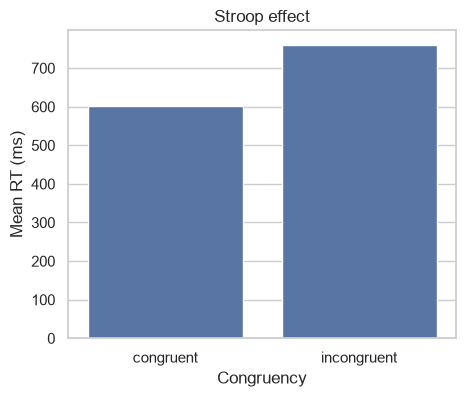

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(
    x=rt_by_congruency.index,
    y=rt_by_congruency.values,
    order=["congruent", "incongruent"],
    ax=ax,
)
ax.set_xlabel("Congruency")
ax.set_ylabel("Mean RT (ms)")
ax.set_title("Stroop effect")
plt.show()